In [73]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping

In [74]:
def load_custom_dataset(data_path, target_size=(32,32)):
    images = []
    labels = [] 
    
    for digit in range(10): 
        folder_path = os.path.join(data_path, str(digit))
        if not os.path.exists(folder_path):
            print(f"folder {folder_path} not exist!") 
            continue
        
        print(f"Uploading folder {digit}...")
        
        for entry in os.scandir(folder_path):
            if not entry.is_file():
                continue
            
            if not entry.name.lower().endswith( ('.png', '.jpg', '.jpeg') ): 
                continue 
            
            img = cv2.imread( entry.path, cv2.IMREAD_GRAYSCALE ) 
            if img is None:
                continue
            
            img = cv2.resize(img, target_size)
            
            images.append(img)
            labels.append(digit)
            
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32) 
            
    images = np.expand_dims(images, axis=-1)
    images /= 255.0
            
    return images, labels

In [75]:
DATA_PATH = "dataset_farsi/"

print("Uploading dataset...")
dataset_file = "farsi_dataset_load_32-32_copy.npz"

if os.path.exists(dataset_file):
    data = np.load(dataset_file)

    X = data["x"]
    y = data["y"]

    print("Dataset loaded from cache")

else:
    X, y = load_custom_dataset(DATA_PATH)

    np.savez_compressed(
        dataset_file,
        x=X,
        y=y
    )

    print("Dataset cached")


print(f"Pictures {len(X)}")
print(f"Pictures shape {X.shape}")
print(f"Picture pre num: {np.bincount(y)}")

Uploading dataset...
Dataset loaded from cache
Pictures 80000
Pictures shape (80000, 32, 32, 1)
Picture pre num: [8000 8000 8000 8000 8000 8000 8000 8000 8000 8000]


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 64000, Test size: 16000


In [77]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10)
])
model.summary()

C:\Users\sara\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [79]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

h = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9511 - loss: 0.1570 - val_accuracy: 0.9854 - val_loss: 0.0466
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9856 - loss: 0.0479 - val_accuracy: 0.9906 - val_loss: 0.0282
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9907 - loss: 0.0319 - val_accuracy: 0.9924 - val_loss: 0.0242
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9924 - loss: 0.0267 - val_accuracy: 0.9925 - val_loss: 0.0228
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9939 - loss: 0.0186 - val_accuracy: 0.9926 - val_loss: 0.0246
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9952 - loss: 0.0161 - val_accuracy: 0.9911 - val_loss: 0.0312
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.9941 - val_loss: 0.0204
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9968 -

In [80]:
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9952


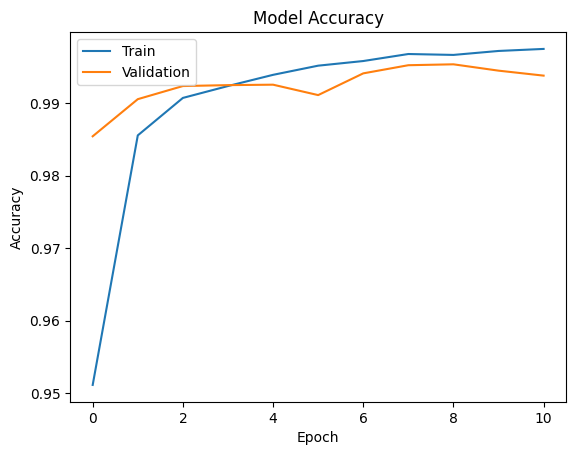

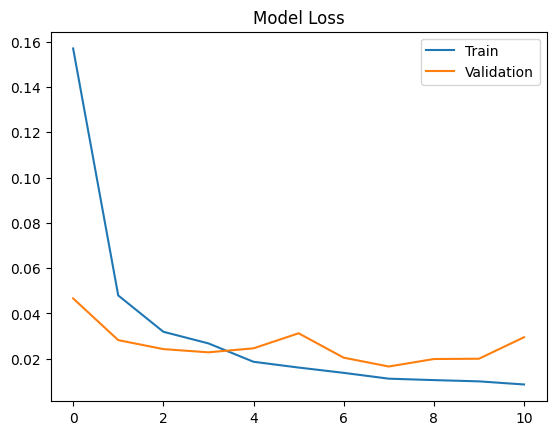

In [81]:
# Model Accuracy
plt.plot(h.history["accuracy"])
plt.plot(h.history["val_accuracy"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# Model Loss
plt.plot(h.history["loss"])
plt.plot(h.history["val_loss"])

plt.title("Model Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()


In [ ]:
# model.load_weights('model2_farsi_dataset_32,32_99.52.h5')

In [ ]:
def predict_digit(image_path, model, target_size=(32,32)):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Not found")
        return None
    
    # To make it like our dataset
    _, img = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    coords = cv2.findNonZero(img)

    x, y, w, h = cv2.boundingRect(coords)

    img = img[y:y+h, x:x+w]

    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=2)
    img = np.expand_dims(img, axis=0)

    img = img / 255.0

    prediction_logits = model.predict(img)
    predicted_digit = np.argmax(prediction_logits)

    probs = tf.nn.softmax(prediction_logits)
    confidence = tf.reduce_max(probs).numpy()

    plt.figure(figsize=(3, 3))
    plt.imshow(img[0, :, :, 0], cmap='gray')
    plt.title(f'Predicted: {predicted_digit} (Confidence: {confidence:.2%})')
    plt.axis('off')
    plt.show()

    return predicted_digit, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


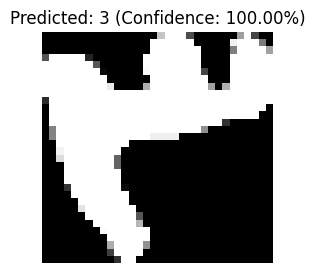

In [85]:
# test with my own data
out2 = predict_digit(r'test pics/test2.png', model)

In [ ]:
# check the number of wrong predicts
pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

wrong = np.where(pred != y_test)[0]

print(len(wrong))

500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
76


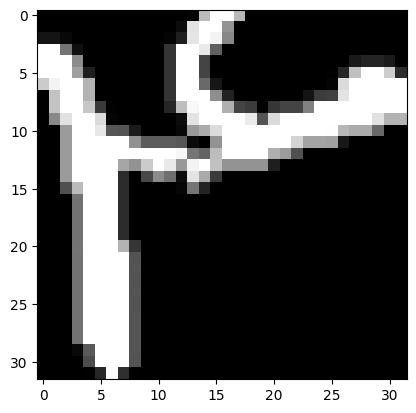

Real: 4
Pred: 3


In [ ]:
# check and see the wrong predicts

i = wrong[0]

plt.imshow(X_test[i,:,:,0], cmap="gray")
plt.show()

print("Real:", y_test[i])
print("Pred:", pred[i])